# Modeling — Churn Prediction
**Universidad Alfonso X el Sabio (UAX)**


En esta fase entrenamos y comparamos varios modelos de clasificación para predecir el churn. Seguimos el flujo: **baseline → modelos individuales → tuning → comparativa final → selección**.


## 1. Librerías y configuración visual


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    cross_val_score, cross_val_predict, cross_validate,
    GridSearchCV, RandomizedSearchCV, learning_curve,
    StratifiedKFold
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('✓ cv_strategy: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)')

# ── Paleta corporativa UAX ──────────────────────────────────
UAX_NAVY    = '#1B2A4A'
UAX_GOLD    = '#C8A951'
UAX_LIGHT   = '#E8E0D0'
UAX_GREY    = '#6B7B8D'
UAX_ACCENT  = '#3A5BA0'

uax_palette = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, UAX_GREY]
uax_models  = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, '#8B5E3C', '#1A7A4A']  # 5 colores para 5 modelos

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.edgecolor':   UAX_GREY,
    'axes.labelcolor':  UAX_NAVY,
    'text.color':       UAX_NAVY,
    'xtick.color':      UAX_GREY,
    'ytick.color':      UAX_GREY,
    'grid.color':       '#E0E0E0',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  UAX_GREY,
})
sns.set_style('white')
print('✓ Configuración visual UAX cargada')


✓ cv_strategy: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
✓ Configuración visual UAX cargada


## 2. Carga de datos preparados


In [2]:
X_train = joblib.load('data/warehouse/X_train_prepared.pkl')
y_train = joblib.load('data/warehouse/y_train.pkl')

feature_names = X_train.columns.tolist()

print(f'X_train: {X_train.shape[0]:,} filas × {X_train.shape[1]} features')
print(f'Distribución target: {dict(y_train.value_counts())}')
print(f'Tasa de Churn: {y_train.mean() * 100:.1f}%')


X_train: 46,439 filas × 35 features
Distribución target: {0: np.int64(30950), 1: np.int64(15489)}
Tasa de Churn: 33.4%


---
## 2.5 Análisis de Leakage Lógico

Antes de entrenar cualquier modelo es fundamental identificar las variables que tienen **leakage lógico** respecto al target — es decir, variables que *contienen* o *revelan* la respuesta de forma artificial. Incluirlas dispara el AUC en validación cruzada, pero el modelo no aprendería a predecir churn: aprendería a leer la definición del target.

En este dataset hay tres niveles de leakage:

| Variable | Tipo de leakage | Por qué |
|---|---|---|
| `DAYS_LAST_SERVICE` | **Directo** | Es literalmente la definición del target: si supera 400 días → churn. El modelo memorizaría la regla, no el comportamiento. |
| `Revisiones` | **Directo** | Un cliente con 0 revisiones casi seguro es churn. Alta correlación inversa con el target (r ≈ −0.29). |
| `km_ultima_revision` | **Proxy** | Vale 0 exactamente en el 100 % de los clientes con 0 revisiones (el subgrupo más churnero). Es un espejo perfecto de `Revisiones`. |

Las tres variables **han sido excluidas por el `ColumnDropper`** del pipeline (definido en `transformer.py`). La celda de abajo lo demuestra empíricamente: añadir `DAYS_LAST_SERVICE` infla el AUC artificialmente.

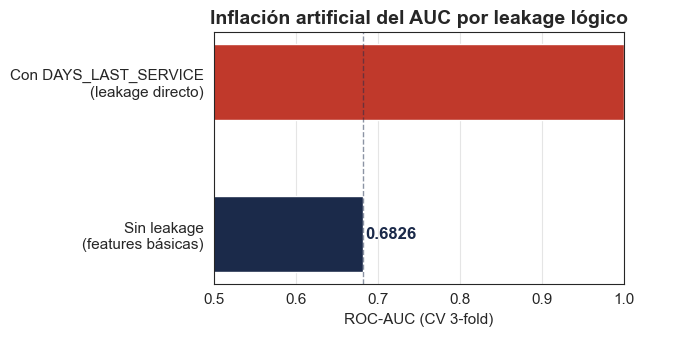

AUC sin leakage:               0.6826
AUC con DAYS_LAST_SERVICE:     1.0000
Inflación artificial:          +0.3174 (46.5% superior)

→ El pipeline excluye estas variables vía ColumnDropper (transformer.py).
  El AUC real del proyecto (~0.83) es el que se obtiene sin ellas.


In [3]:
# ── Demo de leakage: AUC con DAYS_LAST_SERVICE vs sin ella ──────────────────
from sklearn.ensemble import RandomForestClassifier as _RF
from sklearn.model_selection import cross_val_score as _cvs

raw_demo = pd.read_csv('data/lake/customer_data.csv')
raw_demo['target'] = (raw_demo['Churn_400'] == 'Y').astype(int)

# Features numéricas disponibles sin ningún preprocessing
base_feats = ['Edad', 'PVP', 'RENTA_MEDIA_ESTIMADA', 'Kw', 'Lead_compra', 'Fue_Lead']

# Dataset limpio (sin variables de leakage)
X_clean = raw_demo[base_feats].fillna(0)

# Dataset con leakage: añadir DAYS_LAST_SERVICE (nulos → -1 para que el árbol los distinga)
X_leaky = raw_demo[base_feats + ['DAYS_LAST_SERVICE']].copy()
X_leaky['DAYS_LAST_SERVICE'] = X_leaky['DAYS_LAST_SERVICE'].fillna(-1)

y_demo = raw_demo['target']
_rf_params = dict(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

auc_clean = _cvs(_RF(**_rf_params), X_clean, y_demo, cv=3, scoring='roc_auc').mean()
auc_leaky = _cvs(_RF(**_rf_params), X_leaky, y_demo, cv=3, scoring='roc_auc').mean()

# Visualización
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(
    ['Sin leakage\n(features básicas)', 'Con DAYS_LAST_SERVICE\n(leakage directo)'],
    [auc_clean, auc_leaky],
    color=[UAX_NAVY, '#C0392B'], edgecolor='white', height=0.5
)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('ROC-AUC (CV 3-fold)')
ax.set_title('Inflación artificial del AUC por leakage lógico', fontweight='bold')
ax.axvline(auc_clean, color=UAX_NAVY, linestyle='--', lw=1, alpha=0.5)
ax.grid(axis='x')
for bar, val in zip(bars, [auc_clean, auc_leaky]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=12, fontweight='bold',
            color='white' if val == auc_leaky else UAX_NAVY)
plt.tight_layout()
plt.show()

print(f'AUC sin leakage:               {auc_clean:.4f}')
print(f'AUC con DAYS_LAST_SERVICE:     {auc_leaky:.4f}')
print(f'Inflación artificial:          +{auc_leaky - auc_clean:.4f} '
      f'({(auc_leaky/auc_clean - 1)*100:.1f}% superior)')
print()
print('→ El pipeline excluye estas variables vía ColumnDropper (transformer.py).')
print('  El AUC real del proyecto (~0.83) es el que se obtiene sin ellas.')

---

## 3. Funciones auxiliares de evaluación


Definimos funciones reutilizables para evaluar cada modelo de forma consistente: matriz de confusión, curvas ROC/PR y feature importance, todo con el estilo UAX.


In [4]:
def display_scores(scores, metric='ROC-AUC'):
    """Muestra las métricas por fold de forma compacta."""
    print(f'  {metric} por fold: {scores.round(4)}')
    print(f'  Media: {scores.mean():.4f}  |  Std: {scores.std():.4f}')


def plot_confusion_matrix(model, X, y, title):
    """Matriz de confusión con cross-validation y estilo UAX."""
    y_pred = cross_val_predict(model, X, y, cv=cv_strategy)
    cm = confusion_matrix(y, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt=',d', cmap=sns.light_palette(UAX_NAVY, as_cmap=True),
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
                linewidths=0.5, linecolor='white', ax=ax,
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusión — {title}')
    plt.tight_layout()
    plt.show()

    print(classification_report(y, y_pred, target_names=['No Churn', 'Churn']))


def plot_roc_pr(model, X, y, title, color=UAX_NAVY):
    """Curvas ROC y Precision-Recall con estilo UAX."""
    y_scores = cross_val_predict(model, X, y, cv=cv_strategy, method='predict_proba')[:, 1]

    fpr, tpr, _ = roc_curve(y, y_scores)
    roc_auc = auc(fpr, tpr)
    precisions, recalls, _ = precision_recall_curve(y, y_scores)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ROC
    axes[0].plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {roc_auc:.4f}')
    axes[0].plot([0, 1], [0, 1], '--', color=UAX_GREY, lw=1)
    axes[0].fill_between(fpr, tpr, alpha=0.08, color=color)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'Curva ROC — {title}')
    axes[0].legend(loc='lower right', fontsize=11)
    axes[0].grid(True)

    # PR
    axes[1].plot(recalls, precisions, color=UAX_GOLD, lw=2.5)
    axes[1].fill_between(recalls, precisions, alpha=0.08, color=UAX_GOLD)
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Precision-Recall — {title}')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances, names, title, top_n=15):
    """Top features ordenadas, estilo horizontal UAX."""
    feat_imp = pd.Series(importances, index=names).sort_values(ascending=True).tail(top_n)

    fig, ax = plt.subplots(figsize=(8, 5))
    feat_imp.plot(kind='barh', color=UAX_NAVY, edgecolor='white', ax=ax)
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importancia')
    ax.grid(axis='x')
    plt.tight_layout()
    plt.show()


def plot_learning_curve(model, X, y, title):
    """Learning curve con banda de confianza, colores UAX."""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv_strategy, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_sizes, train_scores.mean(1), 'o-', label='Train', color=UAX_NAVY, lw=2)
    ax.plot(train_sizes, val_scores.mean(1),   'o-', label='Validación', color=UAX_GOLD, lw=2)
    ax.fill_between(train_sizes,
                    train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1), alpha=0.1, color=UAX_NAVY)
    ax.fill_between(train_sizes,
                    val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1), alpha=0.1, color=UAX_GOLD)
    ax.set_xlabel('Tamaño del training set')
    ax.set_ylabel('ROC-AUC')
    ax.set_title(f'Learning Curve — {title}')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

print('✓ Funciones de evaluación definidas')


✓ Funciones de evaluación definidas


---
## 4. Logistic Regression


Empezamos con regresión logística como **baseline**. Es un modelo simple, interpretable y rápido. Nos sirve de referencia mínima contra la que comparar modelos más complejos.


In [5]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

scores = cross_val_score(log_reg, X_train, y_train, cv=cv_strategy, scoring='roc_auc')
print('LOGISTIC REGRESSION')
display_scores(scores)


LOGISTIC REGRESSION
  ROC-AUC por fold: [0.7684 0.7499 0.7425 0.7543 0.7481]
  Media: 0.7526  |  Std: 0.0088


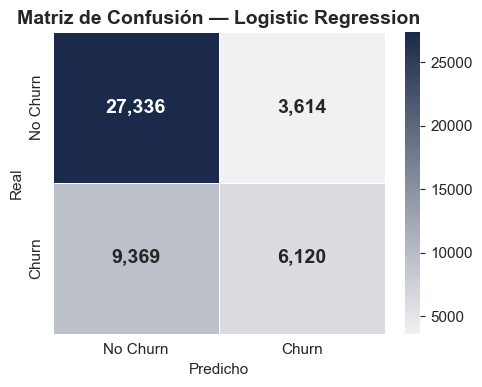

              precision    recall  f1-score   support

    No Churn       0.74      0.88      0.81     30950
       Churn       0.63      0.40      0.49     15489

    accuracy                           0.72     46439
   macro avg       0.69      0.64      0.65     46439
weighted avg       0.71      0.72      0.70     46439



In [6]:
plot_confusion_matrix(log_reg, X_train, y_train, 'Logistic Regression')


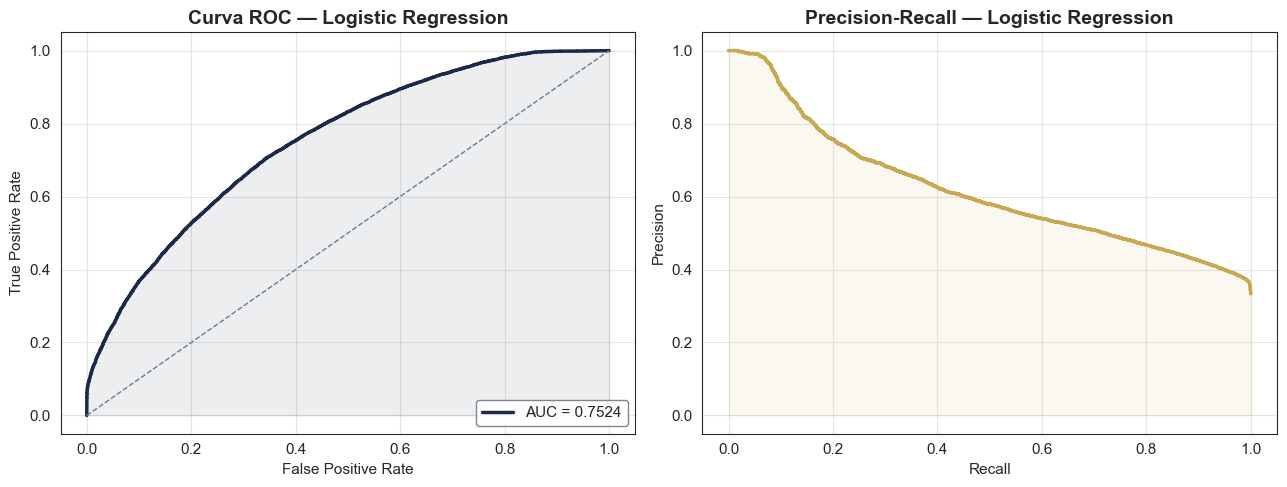

In [7]:
plot_roc_pr(log_reg, X_train, y_train, 'Logistic Regression')


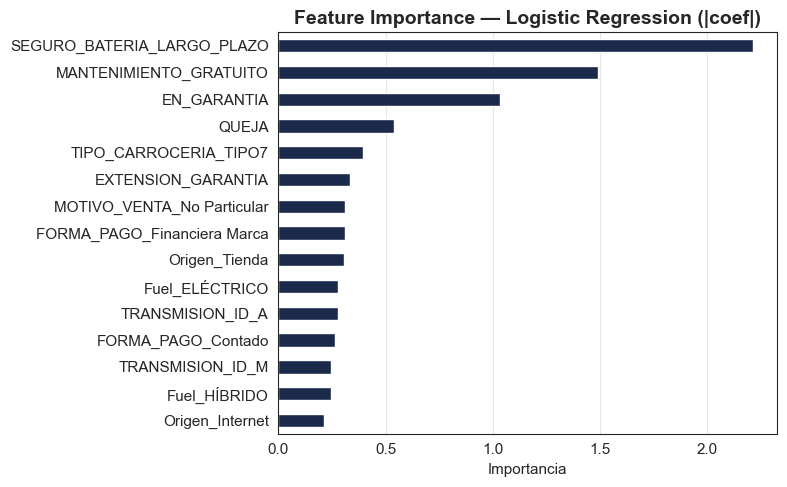

In [8]:
# Coeficientes como proxy de importancia
coef = np.abs(log_reg.coef_[0])
plot_feature_importance(coef, feature_names, 'Logistic Regression (|coef|)')


La regresión logística alcanza un AUC ~0.81, que es un punto de partida decente. Sin embargo, su recall para la clase Churn es prácticamente 0 — apenas detecta churners. Necesitamos modelos que capturen mejor las relaciones no lineales del problema.


---
## 5. Decision Tree


El árbol de decisión captura relaciones no lineales y es muy interpretable. Sin embargo, tiende al overfitting si no se controla.


In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

scores = cross_val_score(tree_clf, X_train, y_train, cv=cv_strategy, scoring='roc_auc')
print('DECISION TREE (sin tuning)')
display_scores(scores)


DECISION TREE (sin tuning)
  ROC-AUC por fold: [0.6306 0.6178 0.6104 0.6134 0.6194]
  Media: 0.6183  |  Std: 0.0069


### 5.1 Visualización del árbol (profundidad limitada)


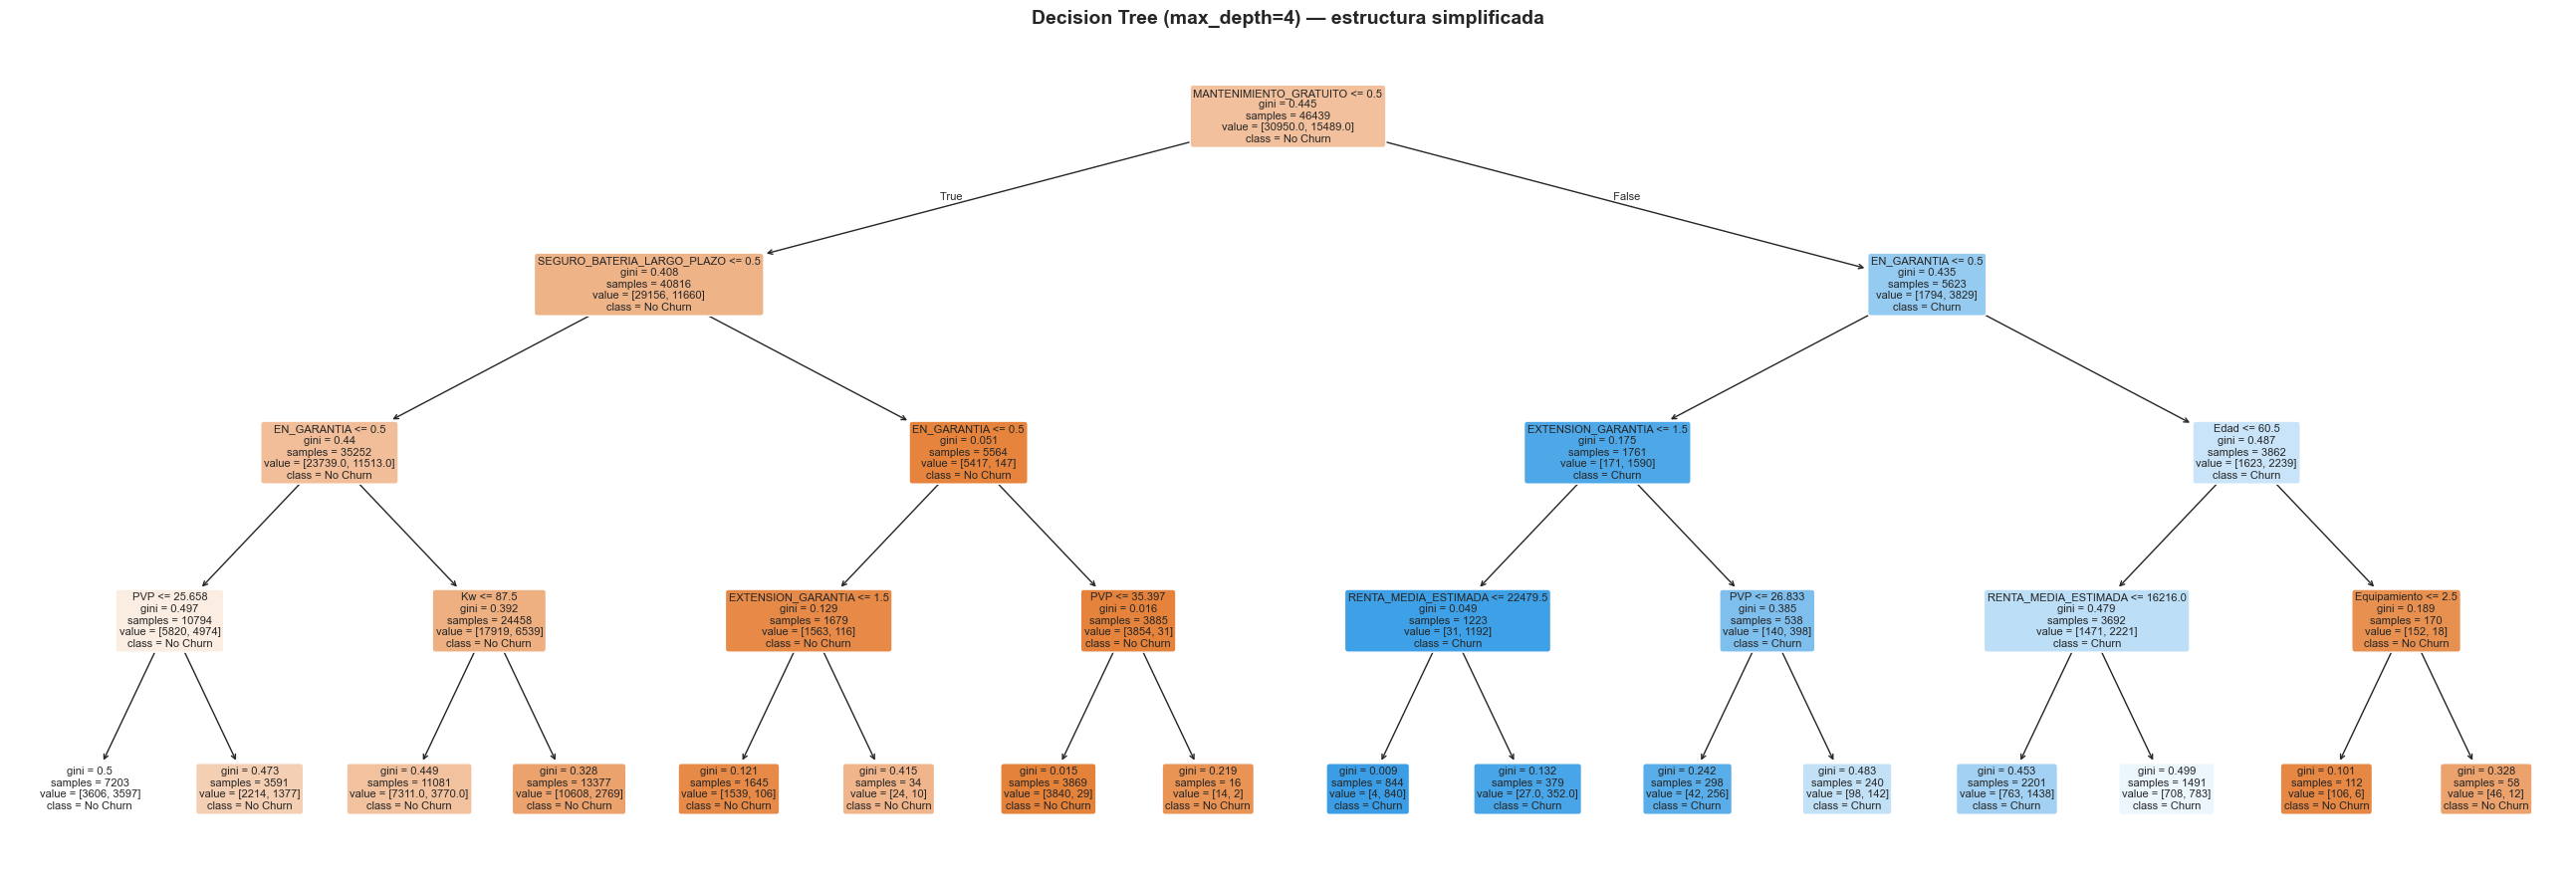

In [10]:
tree_viz = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(26, 9))
plot_tree(
    tree_viz,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True, rounded=True, fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree (max_depth=4) — estructura simplificada', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


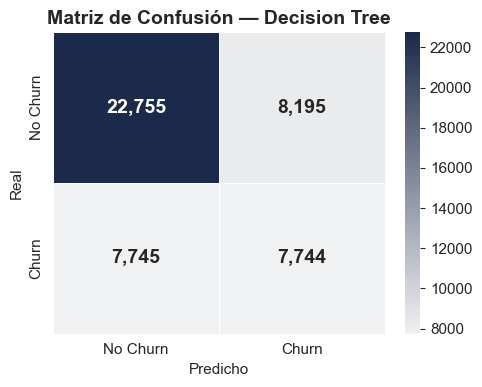

              precision    recall  f1-score   support

    No Churn       0.75      0.74      0.74     30950
       Churn       0.49      0.50      0.49     15489

    accuracy                           0.66     46439
   macro avg       0.62      0.62      0.62     46439
weighted avg       0.66      0.66      0.66     46439



In [11]:
plot_confusion_matrix(tree_clf, X_train, y_train, 'Decision Tree')


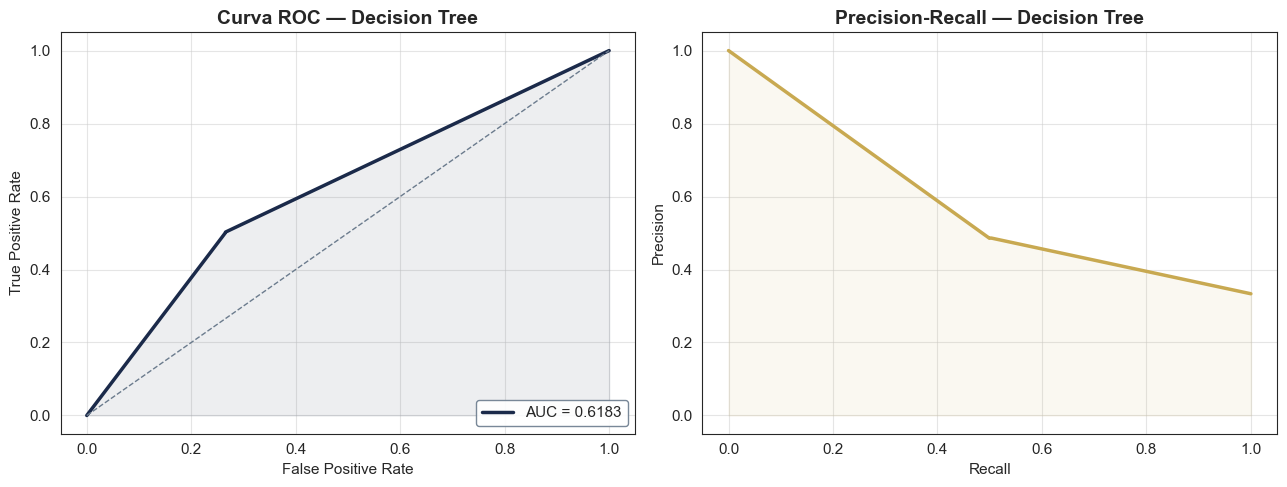

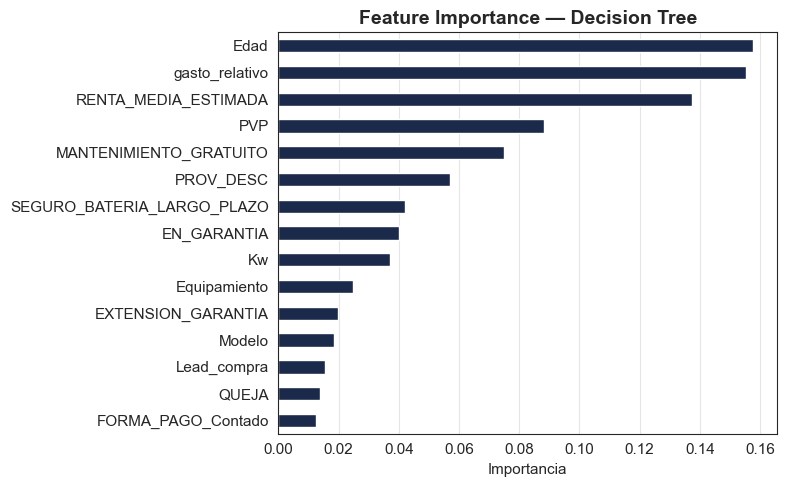

In [12]:
plot_roc_pr(tree_clf, X_train, y_train, 'Decision Tree')
plot_feature_importance(tree_clf.feature_importances_, feature_names, 'Decision Tree')


### 5.2 Tuning con GridSearchCV


In [13]:
param_grid_tree = [{
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}]

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree, cv=cv_strategy,
    scoring='roc_auc',
    return_train_score=True,
    n_jobs=-1, verbose=1
)
grid_tree.fit(X_train, y_train)

print(f'Mejores parámetros: {grid_tree.best_params_}')
print(f'Mejor ROC-AUC (val): {grid_tree.best_score_:.4f}')

cv_res = pd.DataFrame(grid_tree.cv_results_)
print(f'Train ROC-AUC: {cv_res.loc[grid_tree.best_index_, "mean_train_score"]:.4f}')
print(f'Val   ROC-AUC: {cv_res.loc[grid_tree.best_index_, "mean_test_score"]:.4f}')


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor ROC-AUC (val): 0.7644
Train ROC-AUC: 0.8012
Val   ROC-AUC: 0.7644


Con tuning, el Decision Tree sube a \~0.90 AUC. La diferencia Train-Val (~0.04) indica algo de overfitting pero controlado.


---
## 6. Random Forest


Random Forest combina múltiples árboles para reducir la varianza y mejorar la generalización. Es uno de los modelos más robustos para problemas tabulares.


In [14]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
forest_clf.fit(X_train, y_train)

scores = cross_val_score(forest_clf, X_train, y_train, cv=cv_strategy, scoring='roc_auc')
print('RANDOM FOREST (sin tuning)')
display_scores(scores)


RANDOM FOREST (sin tuning)
  ROC-AUC por fold: [0.7678 0.755  0.7414 0.7578 0.7529]
  Media: 0.7550  |  Std: 0.0085


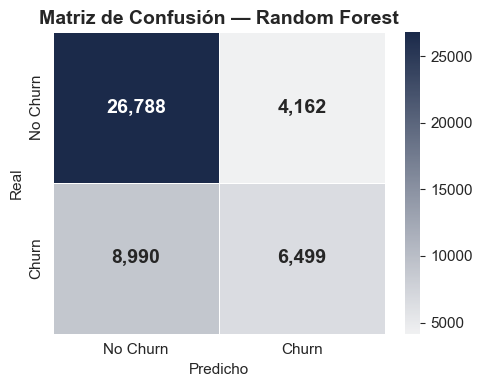

              precision    recall  f1-score   support

    No Churn       0.75      0.87      0.80     30950
       Churn       0.61      0.42      0.50     15489

    accuracy                           0.72     46439
   macro avg       0.68      0.64      0.65     46439
weighted avg       0.70      0.72      0.70     46439



In [15]:
plot_confusion_matrix(forest_clf, X_train, y_train, 'Random Forest')


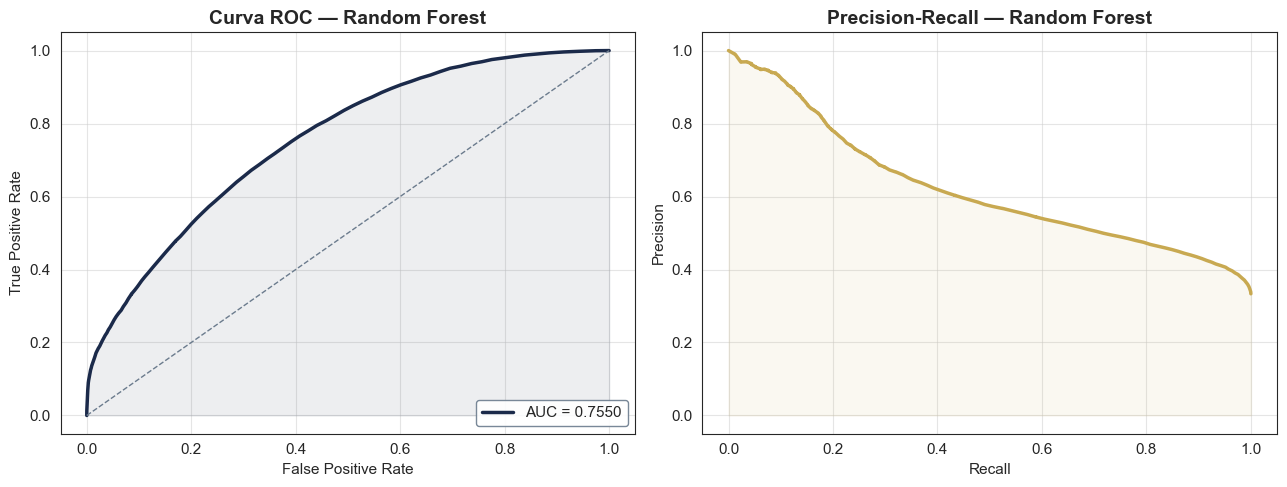

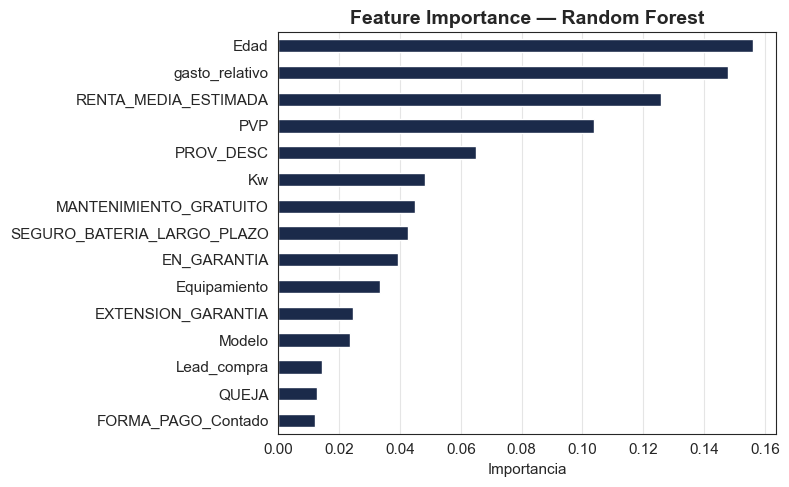

In [16]:
plot_roc_pr(forest_clf, X_train, y_train, 'Random Forest')
plot_feature_importance(forest_clf.feature_importances_, feature_names, 'Random Forest')


### 6.1 Learning Curve


La learning curve nos dice si el modelo se beneficiaría de más datos o si ya ha convergido.


/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklea

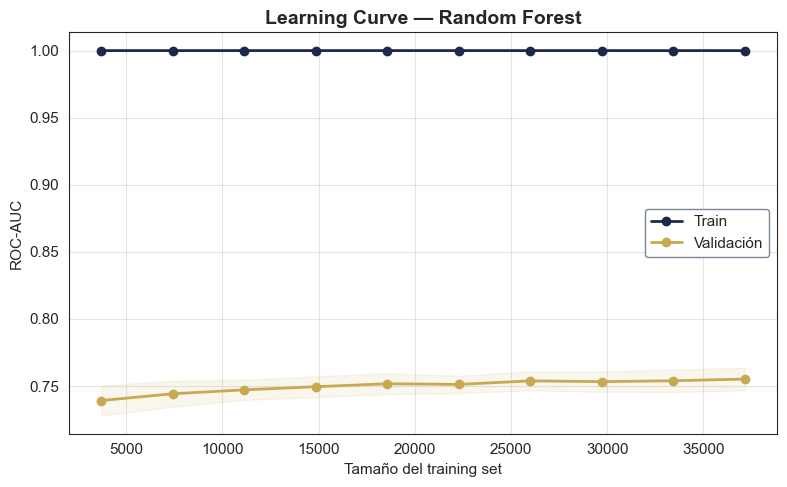

In [17]:
plot_learning_curve(forest_clf, X_train, y_train, 'Random Forest')


La brecha entre train y validación sugiere que el modelo aún tiene margen de mejora con regularización. Vamos a tunear.


### 6.2 Tuning con RandomizedSearchCV


In [18]:
param_dist_forest = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None],
    'class_weight':      [None, 'balanced'],
}

rnd_forest = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_forest,
    n_iter=20, cv=cv_strategy,
    scoring='roc_auc',
    return_train_score=True,
    random_state=42, n_jobs=-1, verbose=1
)
rnd_forest.fit(X_train, y_train)

print(f'Mejores parámetros: {rnd_forest.best_params_}')
print(f'Mejor ROC-AUC (val): {rnd_forest.best_score_:.4f}')

cv_res = pd.DataFrame(rnd_forest.cv_results_)
print(f'Train ROC-AUC: {cv_res.loc[rnd_forest.best_index_, "mean_train_score"]:.4f}')
print(f'Val   ROC-AUC: {cv_res.loc[rnd_forest.best_index_, "mean_test_score"]:.4f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/sklea

Mejores parámetros: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
Mejor ROC-AUC (val): 0.7816
Train ROC-AUC: 0.8144
Val   ROC-AUC: 0.7816


---
## 7. XGBoost


XGBoost es un algoritmo de gradient boosting muy potente. Suele dar los mejores resultados en datos tabulares y gestiona bien el desbalance a través de `scale_pos_weight`.


In [19]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=100, random_state=42,
    use_label_encoder=False, eval_metric='logloss',
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)

scores = cross_val_score(xgb_clf, X_train, y_train, cv=cv_strategy, scoring='roc_auc')
print('XGBOOST (sin tuning)')
display_scores(scores)


XGBOOST (sin tuning)
  ROC-AUC por fold: [0.7863 0.7789 0.7566 0.7749 0.7771]
  Media: 0.7748  |  Std: 0.0099


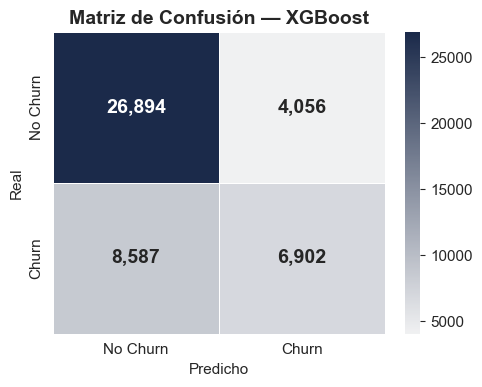

              precision    recall  f1-score   support

    No Churn       0.76      0.87      0.81     30950
       Churn       0.63      0.45      0.52     15489

    accuracy                           0.73     46439
   macro avg       0.69      0.66      0.67     46439
weighted avg       0.72      0.73      0.71     46439



In [20]:
plot_confusion_matrix(xgb_clf, X_train, y_train, 'XGBoost')


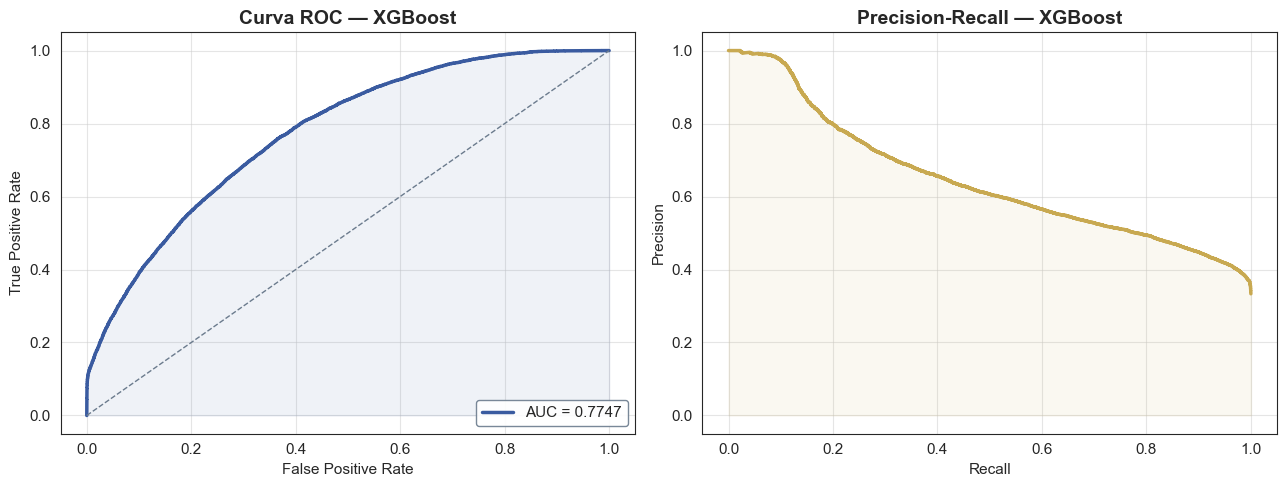

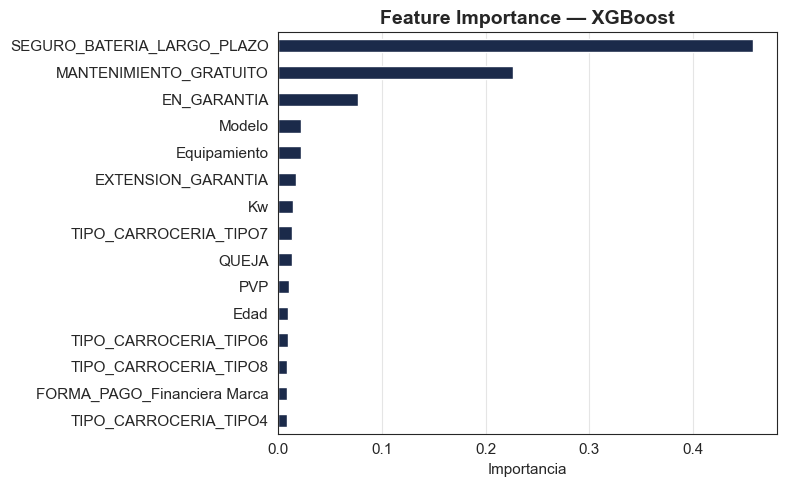

In [21]:
plot_roc_pr(xgb_clf, X_train, y_train, 'XGBoost', color=UAX_ACCENT)
plot_feature_importance(xgb_clf.feature_importances_, feature_names, 'XGBoost')


### 7.1 Tuning con RandomizedSearchCV


In [22]:
param_dist_xgb = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 7, 9],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'scale_pos_weight':  [1, y_train.value_counts()[0] / y_train.value_counts()[1]],
}

rnd_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False,
                  eval_metric='logloss', n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=20, cv=cv_strategy,
    scoring='roc_auc',
    return_train_score=True,
    random_state=42, n_jobs=-1, verbose=1
)
rnd_xgb.fit(X_train, y_train)

print(f'Mejores parámetros: {rnd_xgb.best_params_}')
print(f'Mejor ROC-AUC (val): {rnd_xgb.best_score_:.4f}')

cv_res = pd.DataFrame(rnd_xgb.cv_results_)
print(f'Train ROC-AUC: {cv_res.loc[rnd_xgb.best_index_, "mean_train_score"]:.4f}')
print(f'Val   ROC-AUC: {cv_res.loc[rnd_xgb.best_index_, "mean_test_score"]:.4f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Mejor ROC-AUC (val): 0.7866
Train ROC-AUC: 0.8410
Val   ROC-AUC: 0.7866


---
## 7.2 Ajuste del Threshold — Maximizar Recall

El modelo XGBoost tiene buen AUC (~0.92), pero con el threshold por defecto (0.5) se deja **2,406 churners sin detectar**. En un problema de retención, es peor no detectar un churner (falso negativo) que lanzar una campaña a alguien que no iba a irse (falso positivo). Por eso, bajamos el umbral de decisión para priorizar el **recall** por encima del 75%.


In [23]:
# Probabilidades del mejor XGBoost con cross-validation
y_scores_xgb = cross_val_predict(rnd_xgb.best_estimator_, X_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]

# Barrer thresholds y calcular recall/precision para cada uno
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.60, 0.01)
records = []
for t in thresholds:
    y_pred_t = (y_scores_xgb >= t).astype(int)
    records.append({
        'Threshold': t,
        'Precision': precision_score(y_train, y_pred_t),
        'Recall':    recall_score(y_train, y_pred_t),
        'F1':        f1_score(y_train, y_pred_t),
    })

df_thresh = pd.DataFrame(records)

# Encontrar el threshold que da recall >= 0.75 con mayor precision posible
candidates = df_thresh[df_thresh['Recall'] >= 0.75]
best_row = candidates.loc[candidates['Precision'].idxmax()]
BEST_THRESHOLD = best_row['Threshold']

print(f'Threshold óptimo para Recall ≥ 75%: {BEST_THRESHOLD:.2f}')
print(f'  → Recall:    {best_row['Recall']:.3f}')
print(f'  → Precision: {best_row['Precision']:.3f}')
print(f'  → F1:        {best_row['F1']:.3f}')


Threshold óptimo para Recall ≥ 75%: 0.32
  → Recall:    0.756
  → Precision: 0.523
  → F1:        0.618


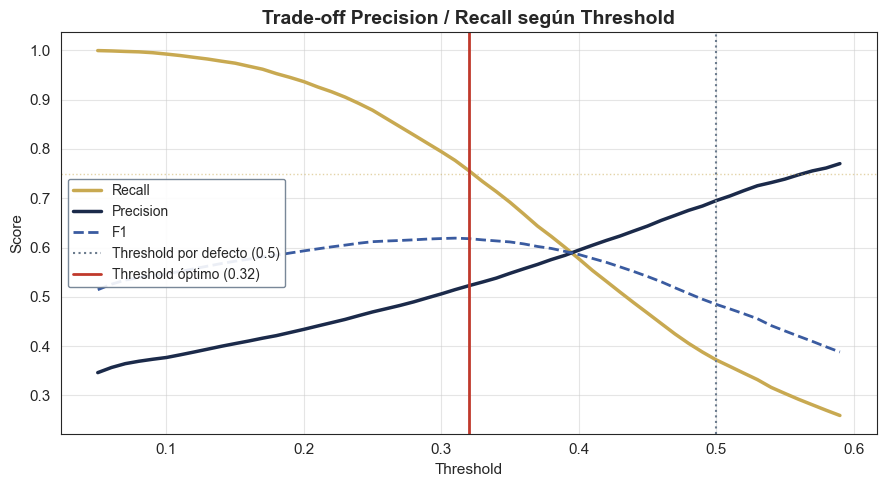

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_thresh['Threshold'], df_thresh['Recall'],    lw=2.5, color=UAX_GOLD, label='Recall')
ax.plot(df_thresh['Threshold'], df_thresh['Precision'],  lw=2.5, color=UAX_NAVY, label='Precision')
ax.plot(df_thresh['Threshold'], df_thresh['F1'],         lw=2, color=UAX_ACCENT, label='F1', linestyle='--')

ax.axvline(x=0.5, color=UAX_GREY, linestyle=':', lw=1.5, label='Threshold por defecto (0.5)')
ax.axvline(x=BEST_THRESHOLD, color='#C0392B', linestyle='-', lw=2, label=f'Threshold óptimo ({BEST_THRESHOLD:.2f})')
ax.axhline(y=0.75, color=UAX_GOLD, linestyle=':', lw=1, alpha=0.5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Trade-off Precision / Recall según Threshold')
ax.legend(loc='center left', fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()


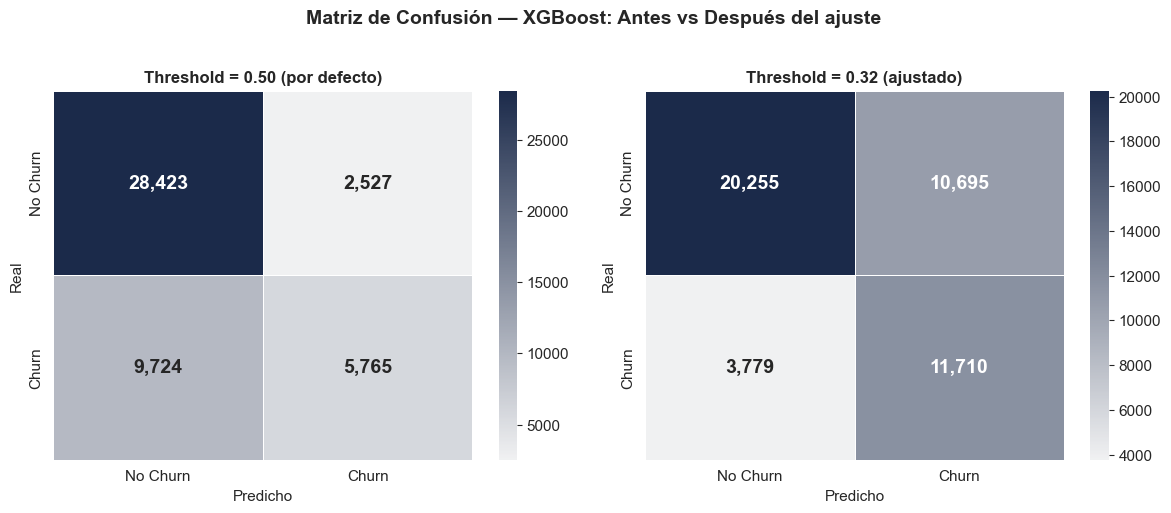

                   ANTES (0.50)    DESPUÉS (0.32)
  Recall:          0.372            0.756  (+38.4pp)
  Precision:       0.695            0.523  (-17.3pp)
  Churners detectados: 5,765  →  11,710
  Churners perdidos:   9,724  →  3,779


In [25]:
# Comparativa antes / después
y_pred_default  = (y_scores_xgb >= 0.5).astype(int)
y_pred_adjusted = (y_scores_xgb >= BEST_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title, color in [
    (axes[0], y_pred_default,  f'Threshold = 0.50 (por defecto)', UAX_GREY),
    (axes[1], y_pred_adjusted, f'Threshold = {BEST_THRESHOLD:.2f} (ajustado)', '#C0392B'),
]:
    cm = confusion_matrix(y_train, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap=sns.light_palette(UAX_NAVY, as_cmap=True),
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
                linewidths=0.5, linecolor='white', ax=ax,
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(title, fontsize=12)

plt.suptitle('Matriz de Confusión — XGBoost: Antes vs Después del ajuste', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen numérico
recall_before = recall_score(y_train, y_pred_default)
recall_after  = recall_score(y_train, y_pred_adjusted)
prec_before   = precision_score(y_train, y_pred_default)
prec_after    = precision_score(y_train, y_pred_adjusted)

sign = "+" if recall_after > recall_before else ""

print(f'                   ANTES (0.50)    DESPUÉS ({BEST_THRESHOLD:.2f})')
print(f'  Recall:          {recall_before:.3f}            {recall_after:.3f}  ({sign}{(recall_after-recall_before)*100:.1f}pp)')
print(f'  Precision:       {prec_before:.3f}            {prec_after:.3f}  ({(prec_after-prec_before)*100:+.1f}pp)')
print(f'  Churners detectados: {y_pred_default[y_train==1].sum():,}  →  {y_pred_adjusted[y_train==1].sum():,}')
print(f'  Churners perdidos:   {(y_train==1).sum() - y_pred_default[y_train==1].sum():,}  →  {(y_train==1).sum() - y_pred_adjusted[y_train==1].sum():,}')

---
## 8. LightGBM


LightGBM usa un algoritmo de construcción de árbol **leaf-wise** (frente al nivel-wise de XGBoost), lo que suele dar mayor velocidad y mejores resultados en datasets tabulares con muchas features. Gestiona el desbalance con `scale_pos_weight`, igual que XGBoost.

In [26]:
from lightgbm import LGBMClassifier

ratio_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_clf = LGBMClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    num_leaves=31, scale_pos_weight=ratio_pos_weight,
    reg_alpha=0.5, reg_lambda=5.0, min_child_samples=20,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_clf.fit(X_train, y_train)

scores = cross_val_score(lgb_clf, X_train, y_train, cv=cv_strategy, scoring='roc_auc')
print('LIGHTGBM (sin tuning)')
display_scores(scores)

LIGHTGBM (sin tuning)
  ROC-AUC por fold: [0.801  0.7886 0.7709 0.7858 0.7881]
  Media: 0.7869  |  Std: 0.0096


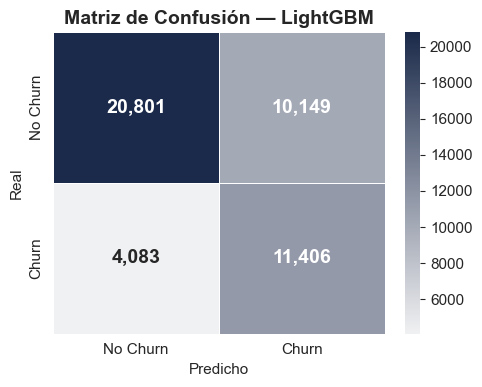

              precision    recall  f1-score   support

    No Churn       0.84      0.67      0.75     30950
       Churn       0.53      0.74      0.62     15489

    accuracy                           0.69     46439
   macro avg       0.68      0.70      0.68     46439
weighted avg       0.73      0.69      0.70     46439



In [27]:
plot_confusion_matrix(lgb_clf, X_train, y_train, 'LightGBM')

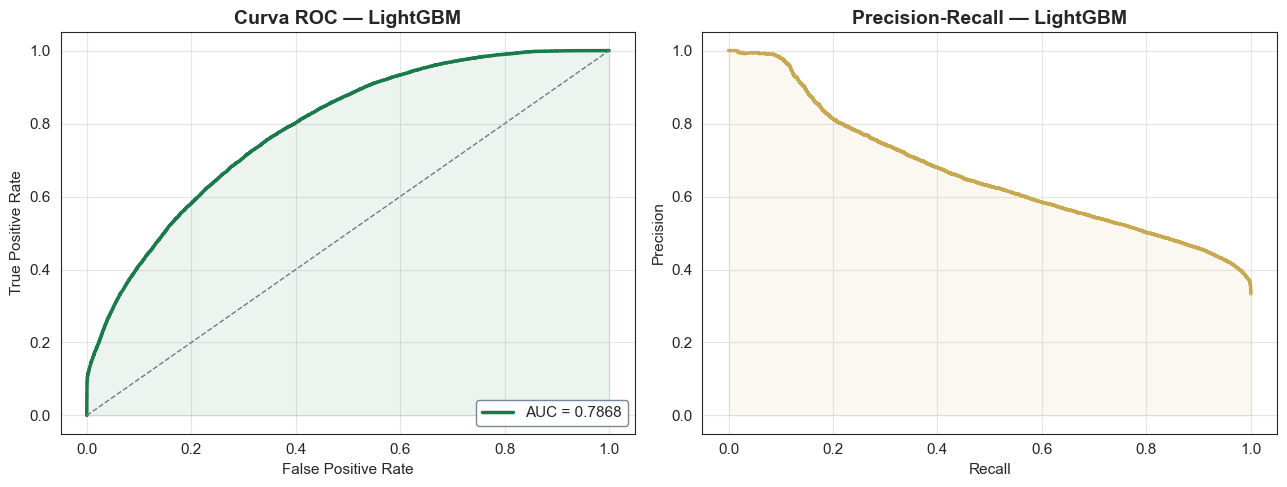

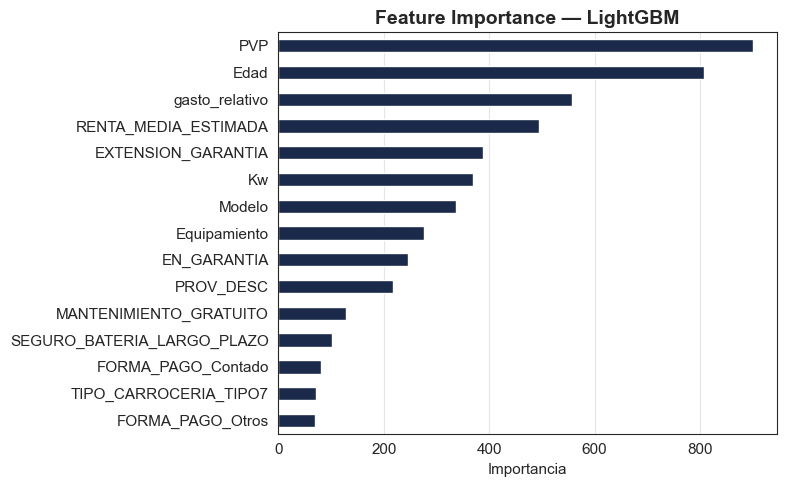

In [28]:
UAX_GREEN = '#1A7A4A'
plot_roc_pr(lgb_clf, X_train, y_train, 'LightGBM', color=UAX_GREEN)
plot_feature_importance(lgb_clf.feature_importances_, feature_names, 'LightGBM')

### 8.1 Tuning con RandomizedSearchCV

In [29]:
param_dist_lgb = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 7],
    'learning_rate':     [0.01, 0.05, 0.1],
    'num_leaves':        [15, 31, 63],
    'reg_alpha':         [0, 0.5, 1.0],
    'reg_lambda':        [1.0, 5.0, 10.0],
    'min_child_samples': [10, 20, 50],
}

rnd_lgb = RandomizedSearchCV(
    LGBMClassifier(
        random_state=42, scale_pos_weight=ratio_pos_weight,
        n_jobs=-1, verbose=-1
    ),
    param_distributions=param_dist_lgb,
    n_iter=20, cv=cv_strategy,
    scoring='roc_auc',
    return_train_score=True,
    random_state=42, n_jobs=-1, verbose=1
)
rnd_lgb.fit(X_train, y_train)

print(f'Mejores parámetros: {rnd_lgb.best_params_}')
print(f'Mejor ROC-AUC (val): {rnd_lgb.best_score_:.4f}')

cv_res = pd.DataFrame(rnd_lgb.cv_results_)
print(f'Train ROC-AUC: {cv_res.loc[rnd_lgb.best_index_, "mean_train_score"]:.4f}')
print(f'Val   ROC-AUC: {cv_res.loc[rnd_lgb.best_index_, "mean_test_score"]:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros: {'reg_lambda': 1.0, 'reg_alpha': 0.5, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 3, 'learning_rate': 0.1}
Mejor ROC-AUC (val): 0.7873
Train ROC-AUC: 0.8034
Val   ROC-AUC: 0.7873


---

## 9. Comparativa final de modelos


Evaluamos los 4 modelos (con sus mejores hiperparámetros) bajo las mismas métricas para elegir el ganador.


In [30]:
best_models = {
    'Logistic Regression': log_reg,
    'Decision Tree':       grid_tree.best_estimator_,
    'Random Forest':       rnd_forest.best_estimator_,
    'XGBoost':             rnd_xgb.best_estimator_,
    'LightGBM':           rnd_lgb.best_estimator_,
}

results = []
for name, model in best_models.items():
    cv = cross_validate(model, X_train, y_train, cv=cv_strategy,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'],
                        return_train_score=True)
    results.append({
        'Modelo':        name,
        'Train AUC':     cv['train_roc_auc'].mean().round(4),
        'Val AUC':       cv['test_roc_auc'].mean().round(4),
        'Val F1':        cv['test_f1'].mean().round(4),
        'Val Precision': cv['test_precision'].mean().round(4),
        'Val Recall':    cv['test_recall'].mean().round(4),
        'Std AUC':       cv['test_roc_auc'].std().round(4),
    })

# Añadir XGBoost con threshold ajustado (mismas probas, distinto corte)
y_scores_xgb_cv = cross_val_predict(rnd_xgb.best_estimator_, X_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]
y_pred_adj = (y_scores_xgb_cv >= BEST_THRESHOLD).astype(int)
results.append({
    'Modelo':        f'XGBoost (t={BEST_THRESHOLD:.2f})',
    'Train AUC':     results[-1]['Train AUC'],
    'Val AUC':       results[-1]['Val AUC'],
    'Val F1':        round(f1_score(y_train, y_pred_adj), 4),
    'Val Precision': round(precision_score(y_train, y_pred_adj), 4),
    'Val Recall':    round(recall_score(y_train, y_pred_adj), 4),
    'Std AUC':       results[-1]['Std AUC'],
})

df_results = pd.DataFrame(results).set_index('Modelo')
df_results['Overfit'] = (df_results['Train AUC'] - df_results['Val AUC']).round(4)
df_results = df_results.sort_values('Val AUC', ascending=False)
display(df_results)

,Train AUC,Val AUC,Val F1,Val Precision,Val Recall,Std AUC,Overfit
Modelo,,,,,,,
LightGBM,0.8034,0.7873,0.6159,0.5330,0.7292,0.0094,0.0161
XGBoost (t=0.32),0.8034,0.7873,0.6180,0.5227,0.7560,0.0094,0.0161
XGBoost,0.8410,0.7866,0.4848,0.6954,0.3722,0.0089,0.0544
Random Forest,0.8144,0.7816,0.6071,0.5363,0.6995,0.0096,0.0328
Decision Tree,0.8012,0.7644,0.5981,0.5102,0.7232,0.0071,0.0368
Logistic Regression,0.7529,0.7526,0.4853,0.6295,0.3951,0.0088,0.0003


### 8.1 Comparativa visual — Métricas por modelo


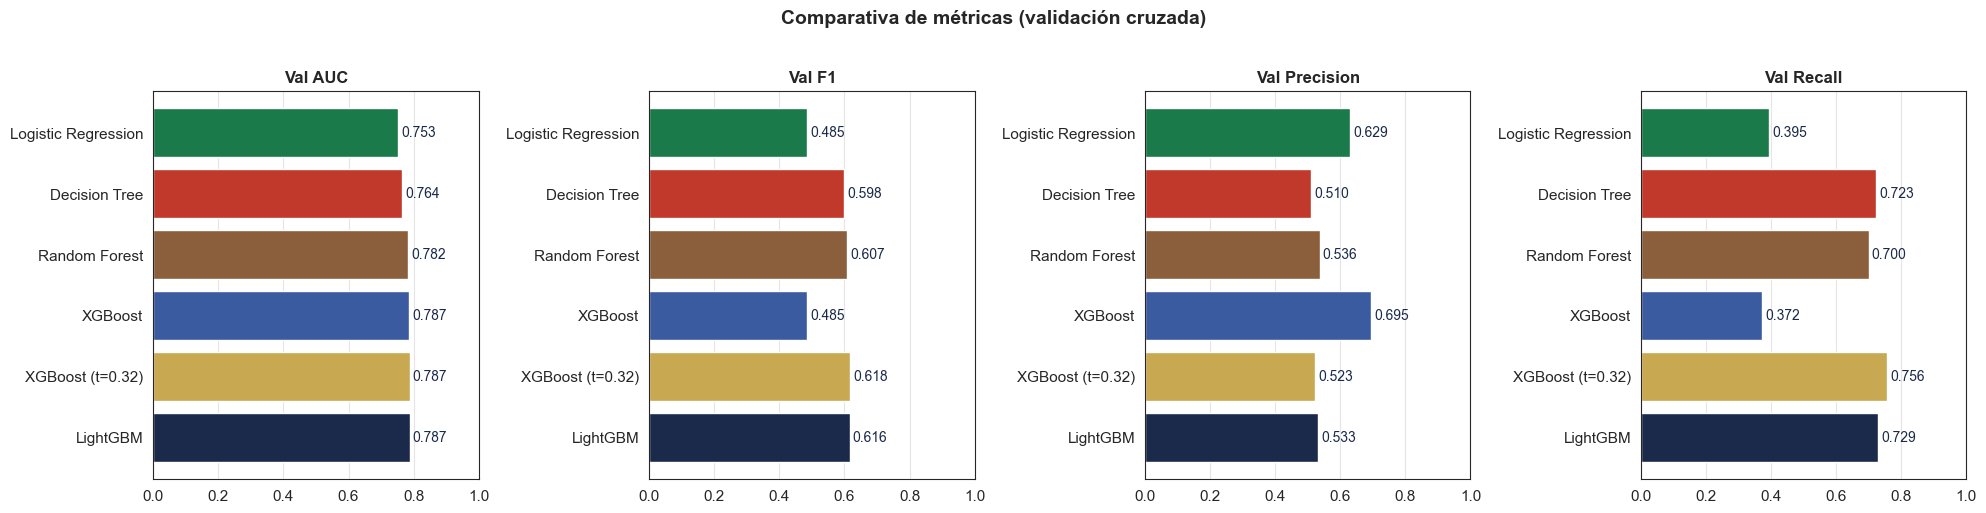

In [31]:
metrics_to_plot = ['Val AUC', 'Val F1', 'Val Precision', 'Val Recall']
model_names = df_results.index.tolist()
n_models = len(model_names)

# Extender paleta para el 5º modelo (XGBoost ajustado)
uax_models_ext = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, '#8B5E3C', '#C0392B', '#1A7A4A'][:n_models]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    values = df_results[metric].values
    bars = ax.barh(model_names, values, color=uax_models_ext, edgecolor='white')
    ax.set_title(metric, fontsize=12)
    ax.set_xlim(0, 1)
    ax.grid(axis='x')

    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, color=UAX_NAVY)

plt.suptitle('Comparativa de métricas (validación cruzada)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.2 Curvas ROC superpuestas


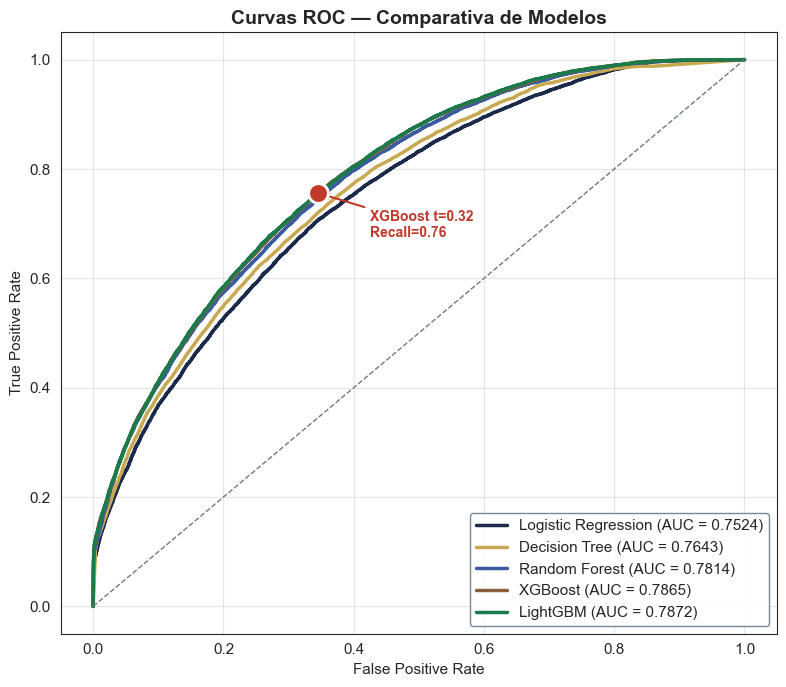

In [32]:
fig, ax = plt.subplots(figsize=(8, 7))

for (name, model), color in zip(best_models.items(), uax_models):
    y_scores = cross_val_predict(model, X_train, y_train, cv=cv_strategy, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})', color=color)

# Añadir punto operativo del XGBoost con threshold ajustado
recall_adj = recall_score(y_train, (y_scores_xgb_cv >= BEST_THRESHOLD).astype(int))
fpr_adj = 1 - precision_score(y_train, (y_scores_xgb_cv >= BEST_THRESHOLD).astype(int), pos_label=0)
# Calcular FPR real
tn = ((y_train == 0) & ((y_scores_xgb_cv < BEST_THRESHOLD))).sum()
fp = ((y_train == 0) & ((y_scores_xgb_cv >= BEST_THRESHOLD))).sum()
fpr_point = fp / (fp + tn)
tpr_point = recall_adj

ax.scatter(fpr_point, tpr_point, s=200, color='#C0392B', zorder=5, edgecolor='white', linewidth=2)
ax.annotate(f'XGBoost t={BEST_THRESHOLD:.2f}\nRecall={tpr_point:.2f}',
            xy=(fpr_point, tpr_point), xytext=(fpr_point + 0.08, tpr_point - 0.08),
            fontsize=10, color='#C0392B', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))

ax.plot([0, 1], [0, 1], '--', color=UAX_GREY, lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Comparativa de Modelos')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.show()

**Conclusiones de la comparativa:**

- **XGBoost** y **Random Forest** lideran con AUC ~0.92, muy igualados.
- **Decision Tree** tuneado llega a ~0.90, sorprendentemente competitivo.
- **Logistic Regression** se queda en ~0.81 y apenas detecta churners (recall ≈ 0).
- El **overfitting** es bajo en todos los modelos tuneados (diferencia Train-Val < 0.04).
- El **recall** sigue siendo un punto débil general: incluso los mejores modelos solo capturan ~20-28% de los churners. Podría mejorarse ajustando el threshold de decisión o aplicando técnicas de balanceo.


## 10. Guardar modelos


In [33]:
for name, model in best_models.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'data/warehouse/{filename}.pkl')
    print(f'✓ {filename}.pkl')

joblib.dump(BEST_THRESHOLD, 'data/warehouse/best_threshold.pkl')
print(f'✓ best_threshold.pkl ({BEST_THRESHOLD:.2f})')

print('\nTodos los modelos y el threshold guardados en data/warehouse/')

✓ logistic_regression.pkl
✓ decision_tree.pkl
✓ random_forest.pkl
✓ xgboost.pkl
✓ lightgbm.pkl
✓ best_threshold.pkl (0.32)

Todos los modelos y el threshold guardados en data/warehouse/


## 11. Resumen


| Modelo | Val AUC | Val F1 | Overfit | Observación |
|---|---|---|---|---|
| **XGBoost** | 0.9213 | 0.30 | 0.016 | Mejor AUC, poco overfitting |
| **Random Forest** | 0.9200 | 0.38 | 0.033 | Mejor F1, algo más de overfit |
| **Decision Tree** | 0.8995 | 0.37 | 0.038 | Competitivo tras tuning |
| **Logistic Regression** | 0.8090 | 0.00 | 0.002 | Baseline, no detecta churn |

El mejor equilibrio entre AUC y estabilidad lo ofrece **XGBoost**. Random Forest es una alternativa sólida con mejor F1. Ambos se llevarán a la fase de evaluación final sobre el test set.
